## Introduction to Fourier Analysis with Python: Notebook 0

In this notebook, we:

    0) Generate and plot sinusoidal signals
    1) Introduce the fast-fourier transform (FFT), perform FFTs of sinusoid.
    2) Add noise to sinusoids, observe the resulting FFT.
    3) Synthesize signals w/ multiple frequency components and take FFT

In [1]:
import numpy as np
import matplotlib.pyplot as plt

## 0) Generate and plot sinusoidal signals

A sinusoidal signal $x(t)$ is specified by it's amplitude $A$, frequency $f$ and phase $\phi$:

$$
    x(t) = A \cdot \cos (2 \pi f t + \phi)
$$

When we represent any signal on a computer, we must break the continuous signal down into discrete "samples" that the computer
can store in memory. A truly continuous signal has an infinite number of points, requiring infinite memory! If we imagine "sampling"
the above continuous signal at equally spaced points in time, separated by a sampling period $T$, we obtain a discrete representation
of the signal:

$$
    x[n] = A \cdot \cos (2\pi f nT + \phi)
$$

Here, we have substituted the continuous time variable $t$, with it's discrete sampled counterpart $nT$. The index variable $n$ is an
integer which we can think of exactly like the index variable into a python array. Let's start by creating a sampled sinusoidal signal
in this manner.

In [2]:
# - define sinusoid parameters - #
A = 1
f = 10
phi = 0

# - create the sampled time vector - #
n = np.arange(1000)
T = 0.001
t = n * T

# - generate the sinusoid - #
x = A*np.cos(2*np.pi*f*t + phi)

In [3]:
x[0:10]

array([1.        , 0.99802673, 0.9921147 , 0.98228725, 0.96858316,
       0.95105652, 0.92977649, 0.90482705, 0.87630668, 0.84432793])

We can plot the sinusoidal signal with the following code:

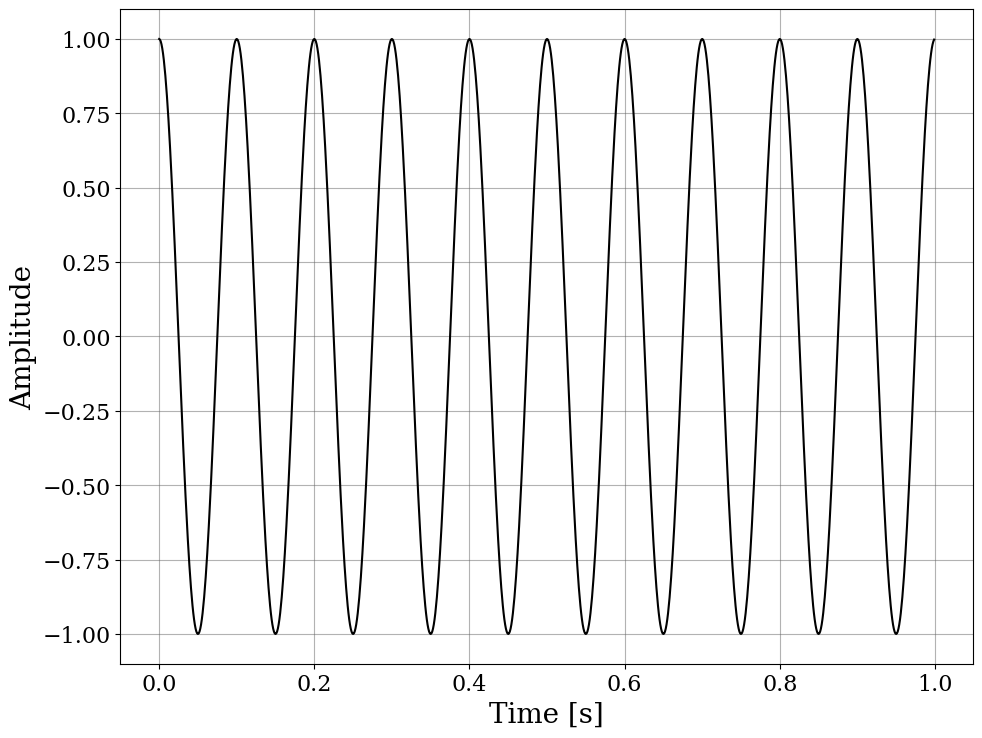

In [4]:
fig, ax = plt.subplots()
ax.set(
    xlabel='Time [s]',
    ylabel='Amplitude',
)

ax.plot(t, x)

The signal plotted above may appear continuous, depending on which sampling period you chose. Don't be fooled however! This is still represented with
a large number of discrete points on our computer. This becomes evident if instead we make a scatter plot of the time and signal vectors.

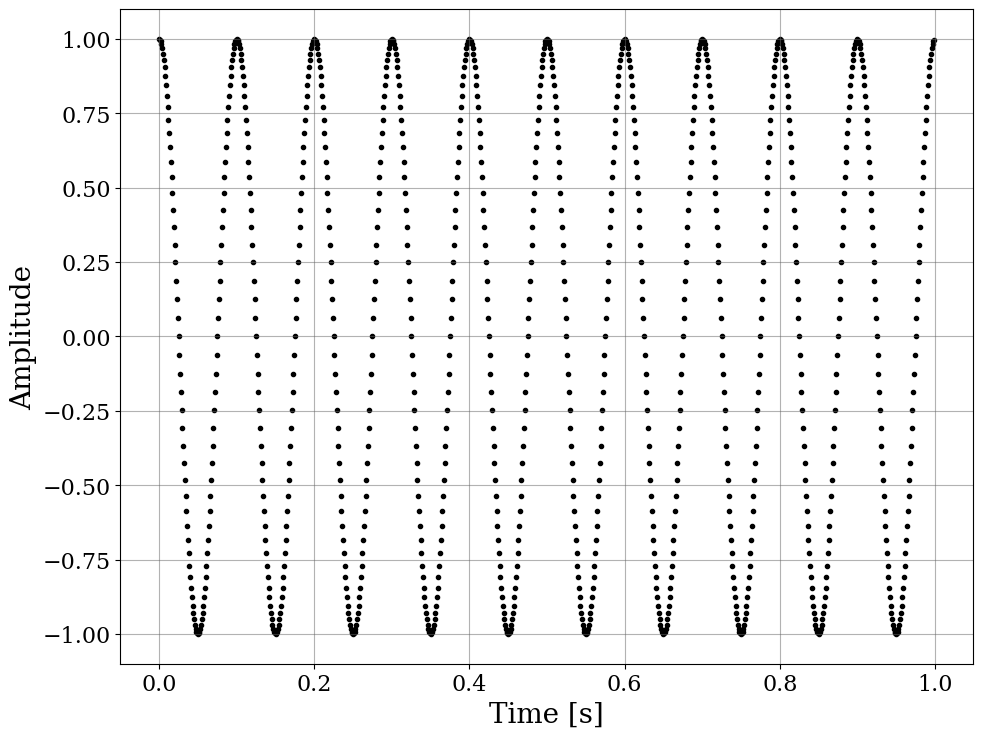

In [5]:
fig, ax = plt.subplots()
ax.set(
    xlabel='Time [s]',
    ylabel='Amplitude',
)

ax.scatter(t, x, marker='.')

For convenience, let's write a function to generate a sinusoid. It will also prove useful later on to write our sampled sinusoid in terms of the
"sampling frequency" $f_s$ instead of the period $T$. The period and sampling frequency are related with:

$$
    T = \frac{1}{f_s}
$$

So, our sampled signal becomes:

$$
    x[n] = A \cos \left( \frac{2\pi f n}{f_s} + \phi \right)
$$

In [6]:
def get_sinusoid(amplitude, frequency, phase, time, sampling_frequency):
    """ Generate a sinusoidal signal with a specified amplitude, frequency, and phase.
    
    :param amplitude: Amplitude of the signal.
    :param frequency: Frequency of the signal.
    :param phase: Offset phase of the signal.
    :param time: How long to sample the signal.
    :param sampling_frequency: How fast to sample the signal.
    """
    t = np.arange(0, time, 1/sampling_frequency)
    x = amplitude*np.cos(2*np.pi*frequency*t + phase)
    return t, x

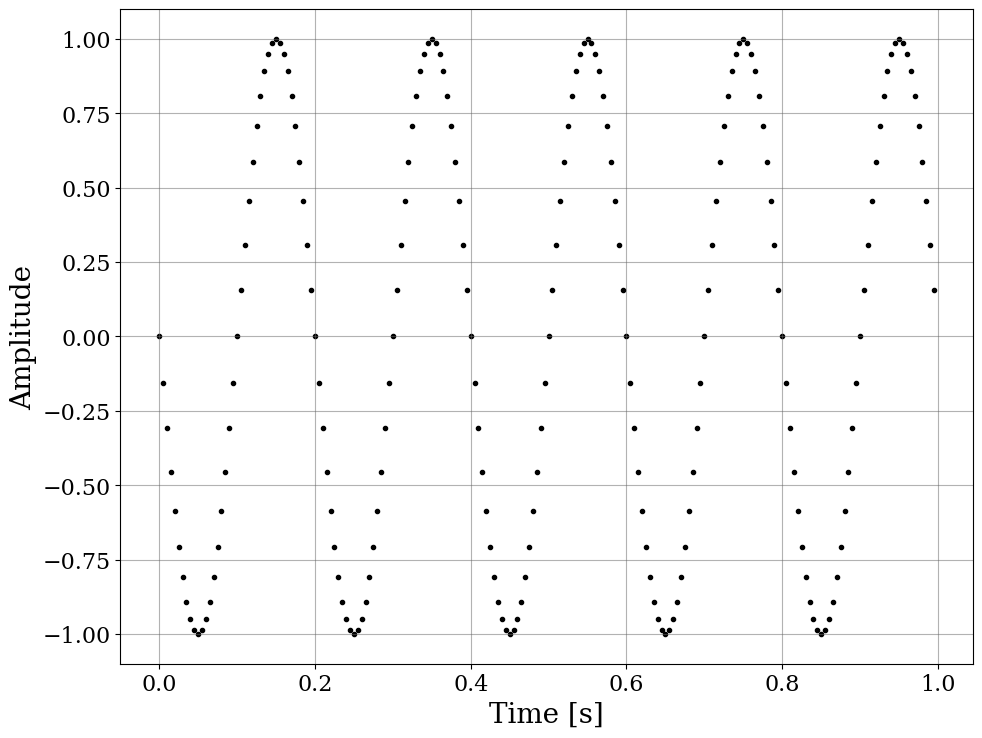

In [7]:
t, x = get_sinusoid(1, 5, np.pi/2, 1, 200)
fig, ax = plt.subplots()
ax.set(
    xlabel='Time [s]',
    ylabel='Amplitude',
)

ax.scatter(t, x, marker='.')

Now, observe what happens when we move from a very fast sample rate to a slower rate

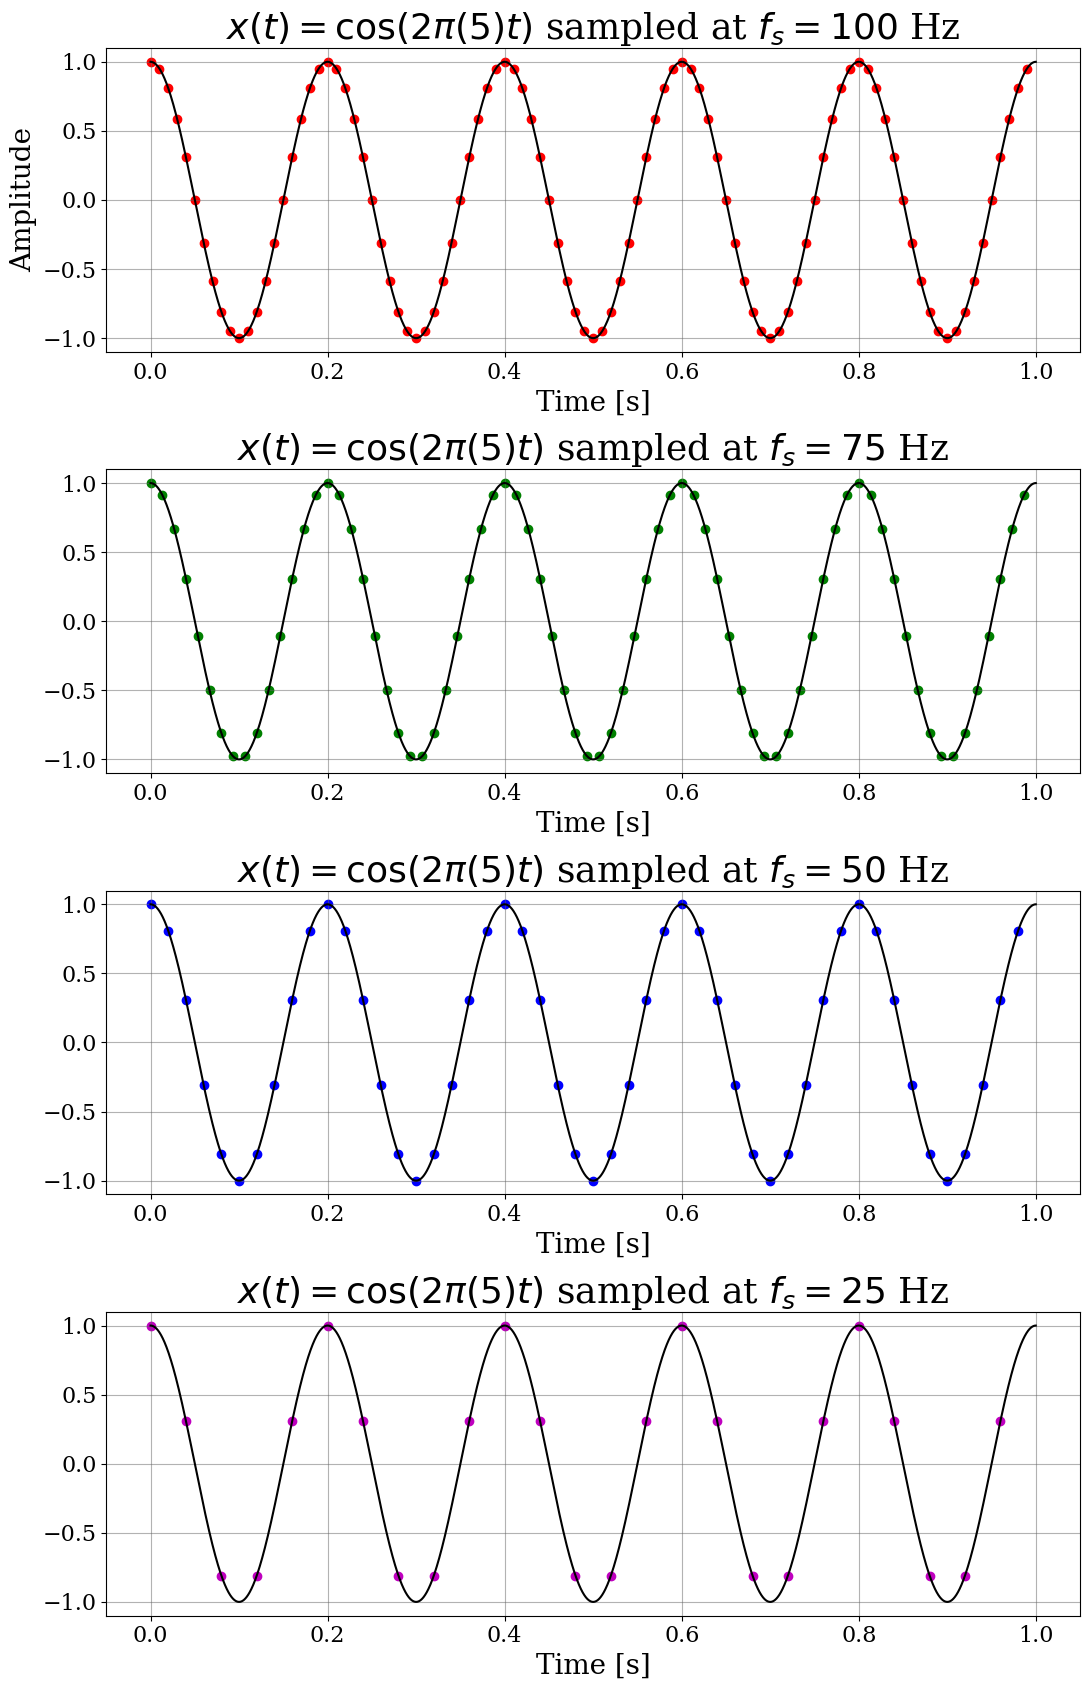

In [8]:
# - sinusoid parameters - #
A = 1
f = 5
phi = 0
time = 1
sample_rate = np.arange(100, 24, -25)

# - make a pseudo-continuous sinusoid to compare on the plot - #
tcts, xcts = get_sinusoid(A, f, phi, time, 10000)

# - set up a plot - #
fig, axs = plt.subplots(sample_rate.shape[0], 1, figsize=(11, 8.5*2))
axs[0].set_ylabel('Amplitude')


colors=['r', 'g', 'b', 'm']
for i, fs in enumerate(sample_rate):
    ax = axs[i]
    ax.set(
        xlabel='Time [s]',
        title=r'$x(t) = \cos (2 \pi (%i) t)$ sampled at $f_s = %i$ Hz' % (f, fs)
    )
    ax.plot(tcts, xcts, c='black')
    t, x = get_sinusoid(A, f, phi, time, fs)
    ax.scatter(t, x, c=colors[i])
    
fig.tight_layout()

## 1) Fast-Fourier Transform (FFT)

Above, we generated single frequency sinusoidal signals, and plotted these signals as a function of time. Now suppose we want to plot
as a function of frequency. Well, because these signals only contain a single frequency, this plot should look simply like a single
spike. The FFT is a numerical method to take a time domain signal and find the frequency at which this spike should be placed. Let's
look at an example. I'll import a function that computes the FFT, which for now, we should treat as a "black-box"

In [9]:
from fft import FFT

Generate a sinudoid, compute it's FFT

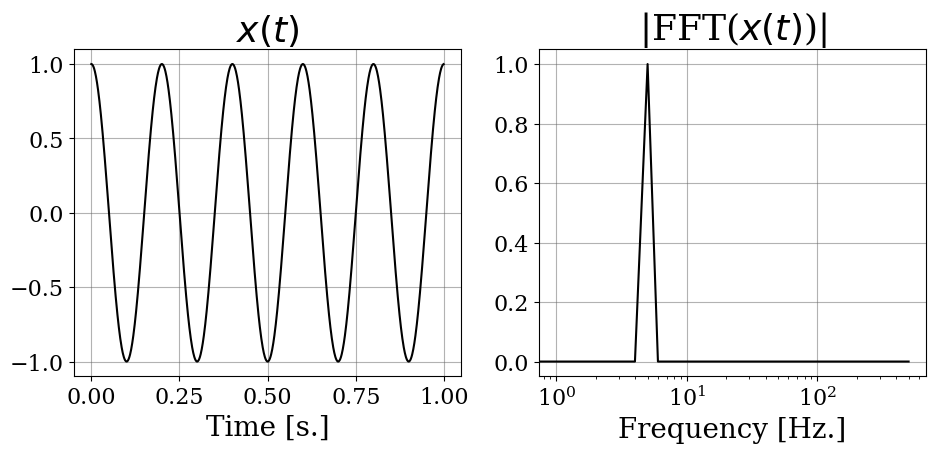

In [10]:
A = 1
f = 5
phi = 0
time = 1
fs = 1000
t, x = get_sinusoid(A, f, phi, time, fs)
freqs, x_fft = FFT(1/fs, x)

fig, axs = plt.subplots(1, 2, figsize=(11, 4.25))
axs[0].set(
    title=r'$x(t)$',
    xlabel='Time [s.]',
)
axs[1].set(
    title=r'|FFT($x(t)$)|',
    xlabel='Frequency [Hz.]',
    xscale='log'
)

axs[0].plot(t, x)
axs[1].plot(freqs, x_fft)

We chose an $f = 5 \text{ Hz.}$ signal and see that indeed, it's FFT is a spike at 5 Hz.

## 2) Add noise to a single sinusoid, observe the resulting FFT

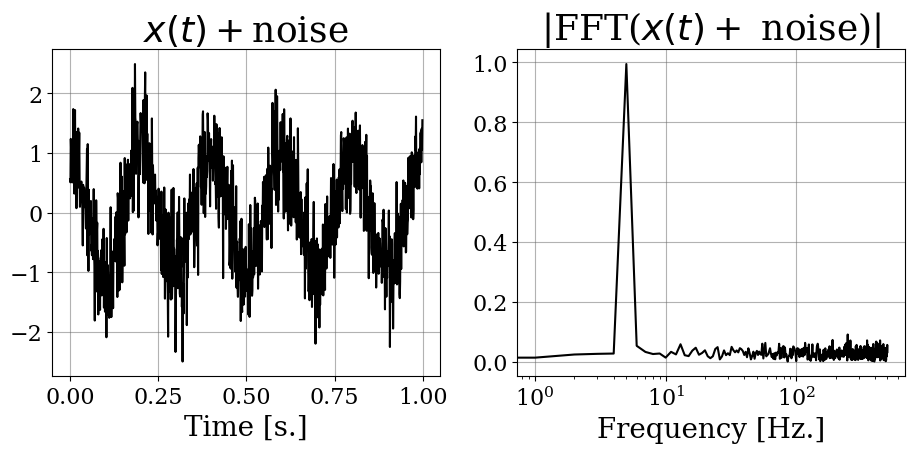

In [11]:
# - generate signal - #
A = 1
f = 5
phi = 0
time = 1
fs = 1000
t, x = get_sinusoid(A, f, phi, time, fs)

# - generate white noise - #
mean = 0
std_dev = 0.5
size = t.shape[0]
noise = np.random.normal(loc=mean, scale=std_dev, size=size)

# - Plot the noisy signal and it's fft - #
noisy_x = x + noise
freqs, noise_x_fft = FFT(1/fs, noisy_x)

# - plot - #
fig, axs = plt.subplots(1, 2, figsize=(11, 4.25))
axs[0].set(
    title=r'$x(t) + $noise',
    xlabel='Time [s.]',
)
axs[1].set(
    title=r'|FFT($x(t) + $ noise)|',
    xlabel='Frequency [Hz.]',
    xscale='log',
)

axs[0].plot(t, noisy_x)
axs[1].plot(freqs, noise_x_fft)

Repeating the above code block, this time with more noise (see that all we've changed is the line `std_dev = 3`) we see that we can still make out the peak at the 5 Hz frequency!
This highlights one useful feature of the FFT. Even with a lot of noise, the FFT "knows" what the fundamental frequency of the signal is. Try changing the parameters of the noise
and seeing how this effects the resulting FFT!

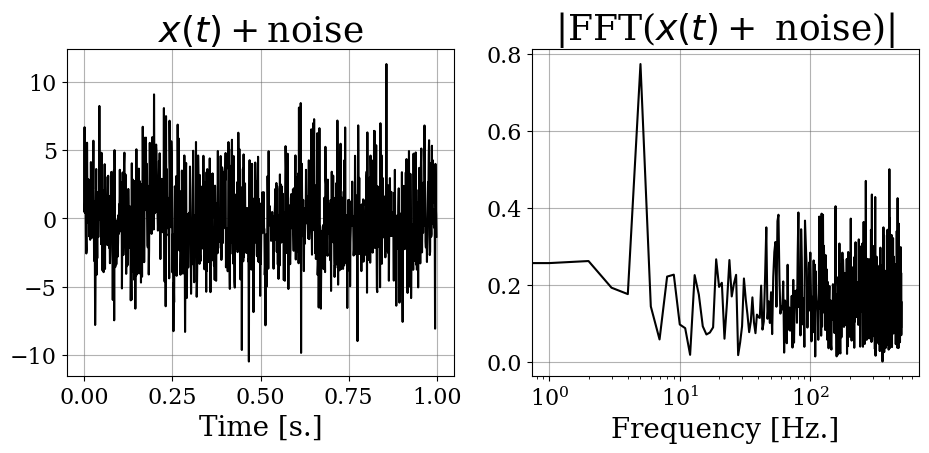

In [12]:
# - generate signal - #
A = 1
f = 5
phi = 0
time = 1
fs = 1000
t, x = get_sinusoid(A, f, phi, time, fs)

# - generate white noise - #
mean = 0
std_dev = 3
size = t.shape[0]
noise = np.random.normal(loc=mean, scale=std_dev, size=size)

# - Plot the noisy signal and it's fft - #
noisy_x = x + noise
freqs, noise_x_fft = FFT(1/fs, noisy_x)

# - plot - #
fig, axs = plt.subplots(1, 2, figsize=(11, 4.25))
axs[0].set(
    title=r'$x(t) + $noise',
    xlabel='Time [s.]',
)
axs[1].set(
    title=r'|FFT($x(t) + $ noise)|',
    xlabel='Frequency [Hz.]',
    xscale='log',
)

axs[0].plot(t, noisy_x)
axs[1].plot(freqs, noise_x_fft)

## 3) Synthesize signals with multiple frequency components

Above, we only considered single tone (frequency) signals. In fact, the FFT can pick up multiple frequency components in a signal. We can see this easily, by creating the following signal:

$$
    x(t) = A\cos(2\pi f_1 t + \phi_1) + B\cos(2\pi f_2 t + \phi_2)
$$

First, let's generate each component of this signal individually, then create the total signal $x(t)$ and plot each component in the time domain:

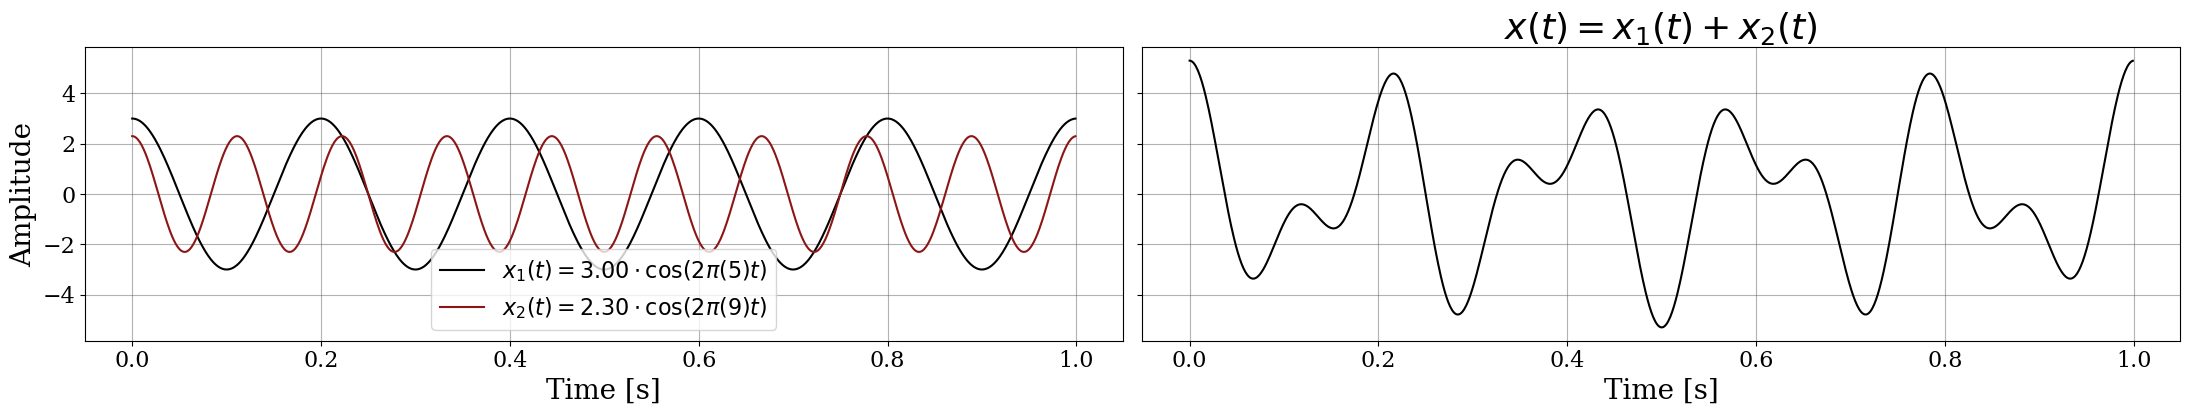

In [13]:
f1 = 5
f2 = 9
fs = 1000
A = 3
B = 2.3
time = 1

t, x1 = get_sinusoid(A, f1, 0, time, fs)
_, x2 = get_sinusoid(B, f2, 0, time, fs)
x = x1 + x2

fig, axs = plt.subplots(1, 2, figsize=(22, 4.25), sharey=True)
axs[0].set(
    xlabel='Time [s]',
    ylabel='Amplitude',
)
axs[1].set(
    xlabel='Time [s]',
    title=r'$x(t) = x_1(t) + x_2(t)$'
)
axs[0].plot(t, x1, label=r'$x_1(t) = %0.2f\cdot \cos(2\pi (%i) t)$' % (A, f1))
axs[0].plot(t, x2, label=r'$x_2(t) = %0.2f\cdot \cos(2\pi (%i) t)$' % (B, f2))
axs[1].plot(t, x)

axs[0].legend()
fig.tight_layout()

Taking the FFT, we see two spikes at the frequencies $f_1$ and $f_2$. The FFT even correctly picks out the amplitudes $A$ and $B$!

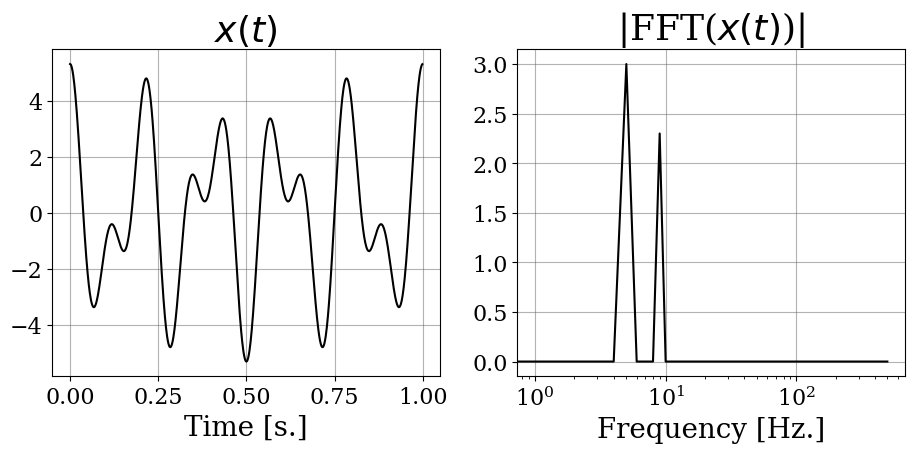

In [14]:
freqs, x_fft = FFT(1/fs, x)

fig, axs = plt.subplots(1, 2, figsize=(11, 4.25))
axs[0].set(
    title=r'$x(t)$',
    xlabel='Time [s.]',
)
axs[1].set(
    title=r'|FFT($x(t)$)|',
    xlabel='Frequency [Hz.]',
    xscale='log'
)

axs[0].plot(t, x)
axs[1].plot(freqs, x_fft)

Let's add some noise to this again to confirm that the peaks remain resolvable using the FFT (up to a reasonable amount of noise)

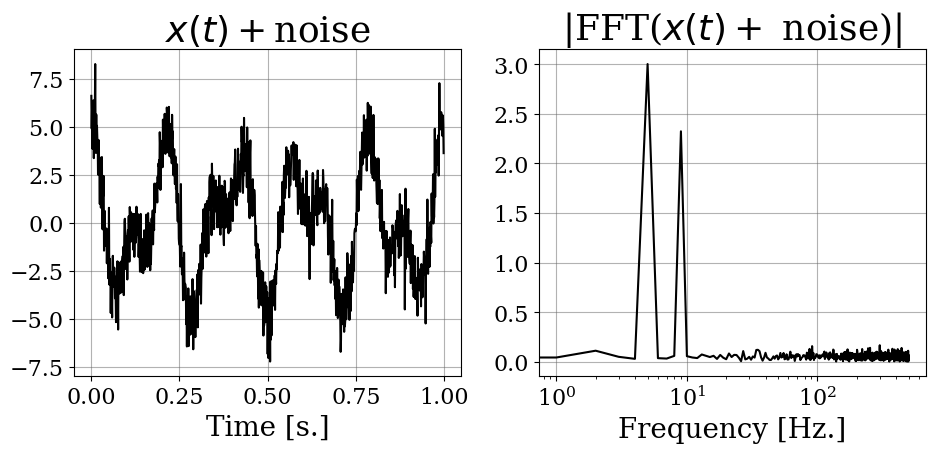

In [15]:
# - generate white noise - #
mean = 0
std_dev = 1
size = t.shape[0]
noise = np.random.normal(loc=mean, scale=std_dev, size=size)

# - Plot the noisy signal and it's fft - #
noisy_x = x + noise
freqs, noise_x_fft = FFT(1/fs, noisy_x)

# - plot - #
fig, axs = plt.subplots(1, 2, figsize=(11, 4.25))
axs[0].set(
    title=r'$x(t) + $noise',
    xlabel='Time [s.]',
)
axs[1].set(
    title=r'|FFT($x(t) + $ noise)|',
    xlabel='Frequency [Hz.]',
    xscale='log',
)

axs[0].plot(t, noisy_x)
axs[1].plot(freqs, noise_x_fft)